# BTSP in a T-maze

* T-maze, largely fixed direction navigation, randomly selecting target arm on each trajectory
* CA3: 40 preset place fields
* CA1: 
  * Hebbian learning + BTSP learning at targeted neurons
  * BTSP learning: long-tailed (pre) Hebbian learning with a high output firing rate considered (occurs in one trajectory only)
  * (1) 1 cell, receives BTSP signal at a reward location

Evaluate resulting CA1 neuron place field properties

In [91]:
import copy
from typing import Any
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_fcts
from predhpc.neurons import learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import plot_util, params_util

In [92]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [93]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

## Reload

In [94]:
import importlib
importlib.reload(agent)
importlib.reload(env)
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(params_util);

## T-maze BTSP

 51%|█████     | 4071/8000 [00:05<00:05, 777.45it/s]


Trajectory lengths (7) to date: 17.45 +/- 1.01 sec each
Trajectory lengths (7) to date: 581.71 +/- 33.63 steps each


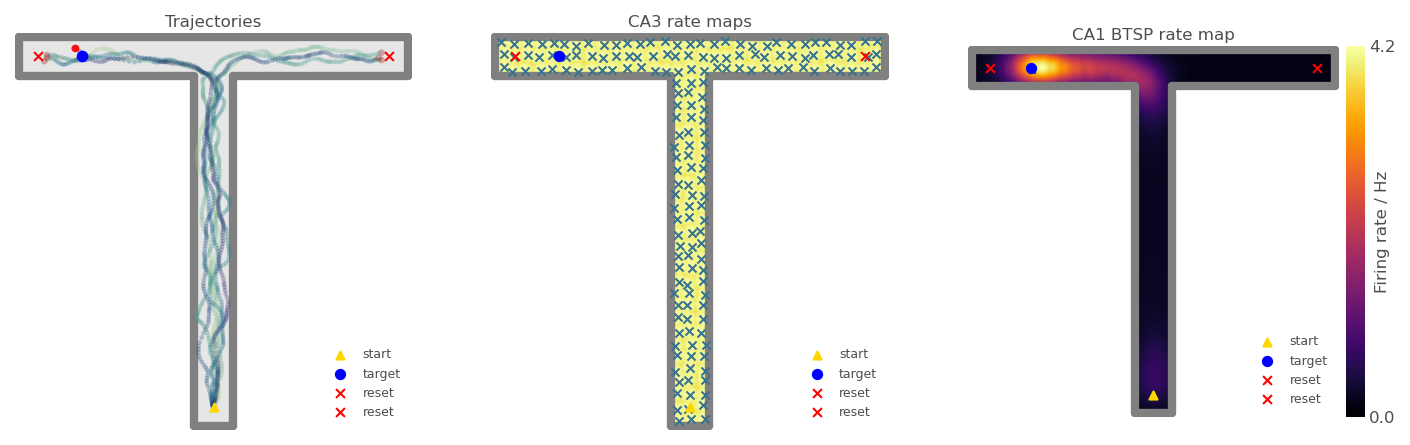

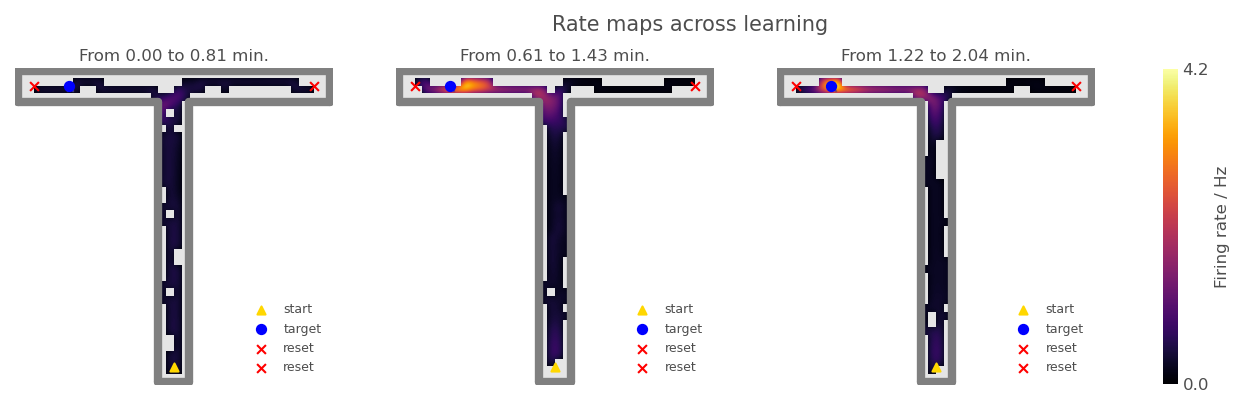

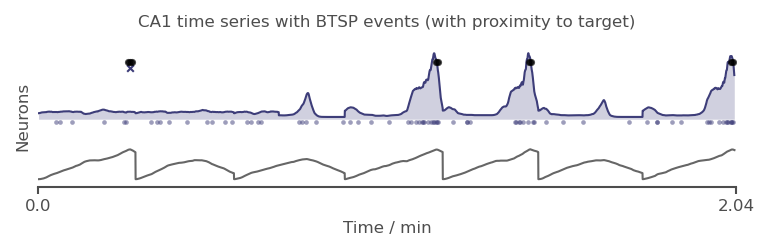

In [95]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter",
)

CA1s = run_manager.learn_T_maze_BTSP(
    CA3_PC_params=CA3_PC_params,
    num_rewards=8, 
    max_num_steps=8000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2,
    two_compartment=False
)

_, Ag, CA3_PCs, CA1s, ECs = run_manager.extract_objects_from_CA1s(CA1s)

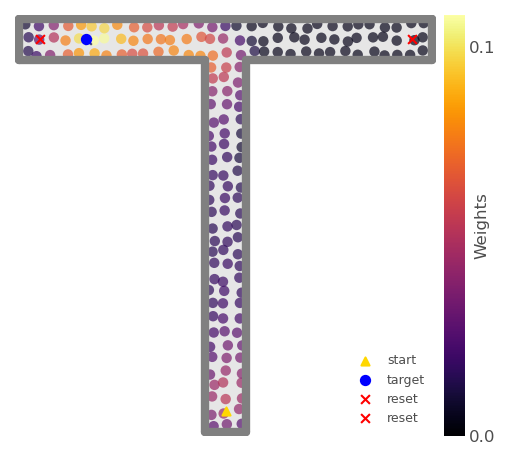

In [96]:
fig, ax = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s, ax=ax, s=25, plot_BTSP_events=True);

## Distance to target

8


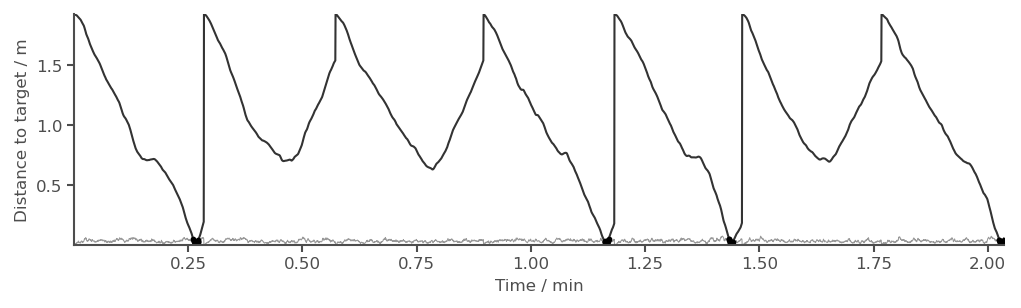

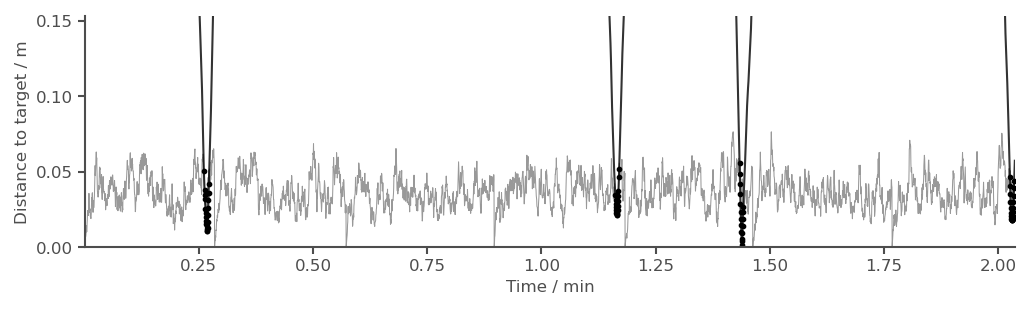

In [97]:
Ag.plot_distance_to(mark_below_tolerance=True)
Ag.plot_distance_to(zoom_prop=2, mark_below_tolerance=True)
print(Ag.target_reached_within_tol_prop_to_speed_dt)

## BTSP filtered inputs

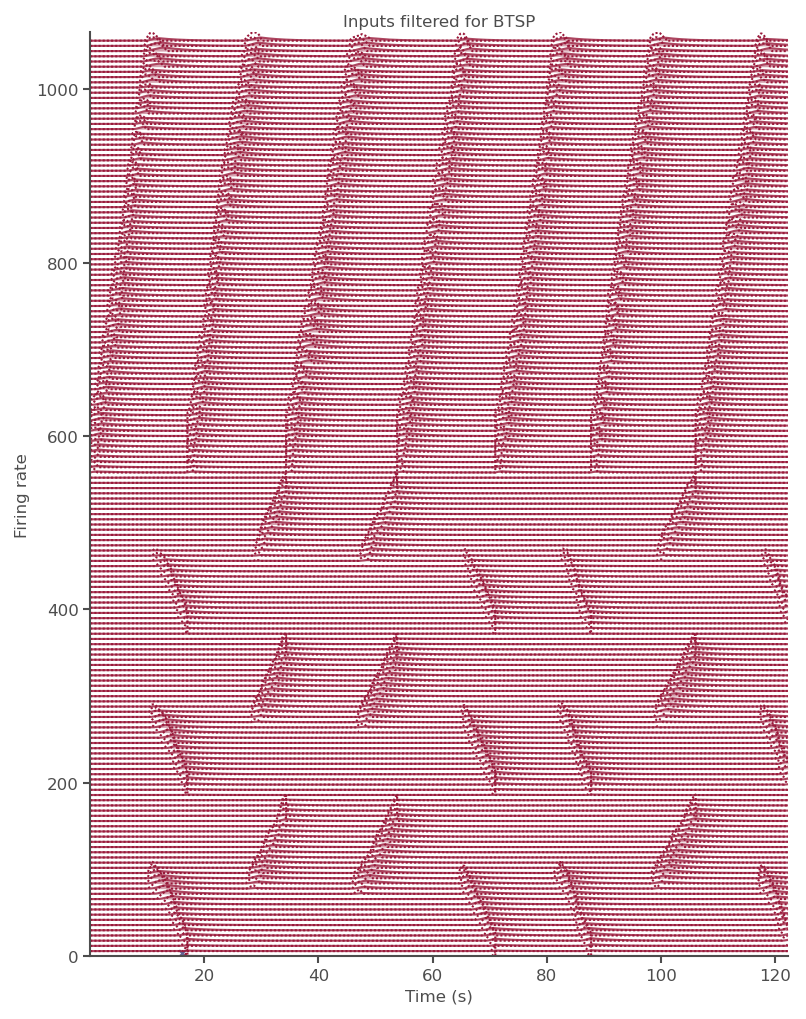

In [98]:
CA1s.plot_filtered_for_BTSP("CA3_PCs");

# BTSP 2-compartment independent

In [99]:
import importlib
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(agent)
importlib.reload(env)

from tqdm import tqdm

In [100]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

agent_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

CA1_params = params_util.get_CA1_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=400,
)

100%|██████████| 4000/4000 [00:08<00:00, 498.91it/s]


Only reached the reward 3 times (target: 8).
Trajectory lengths (7) to date: 17.14 +/- 1.55 sec each
Trajectory lengths (7) to date: 571.43 +/- 51.69 steps each


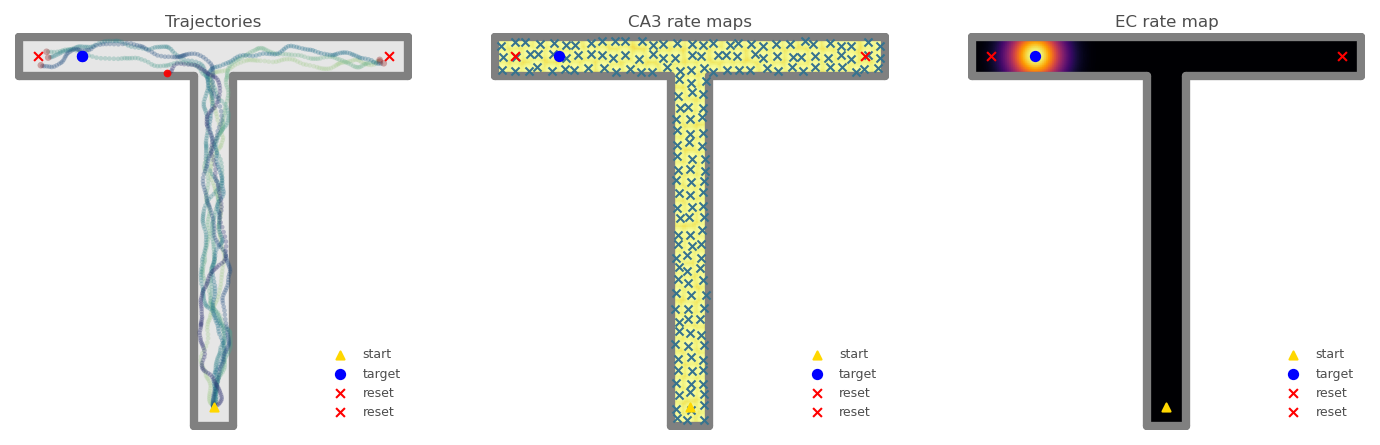

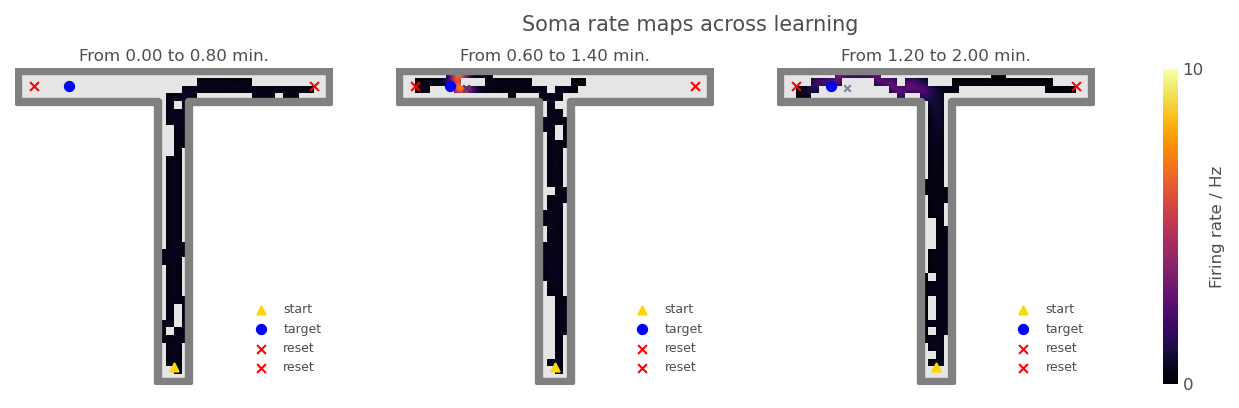

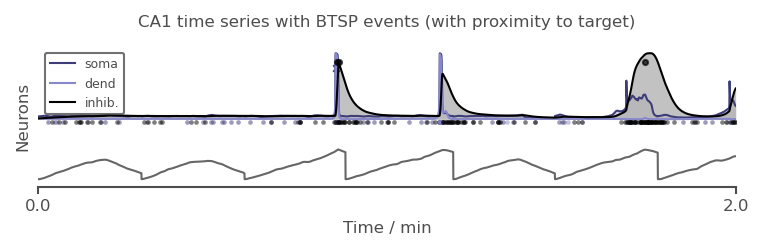

In [101]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

CA1s = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    CA3_PC_params=CA3_PC_params, 
    CA1_params=CA1_params, 
    num_rewards=8, 
    max_num_steps=4000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

_, Ag, CA3_PCs, CA1s, ECs = run_manager.extract_objects_from_CA1s(CA1s)

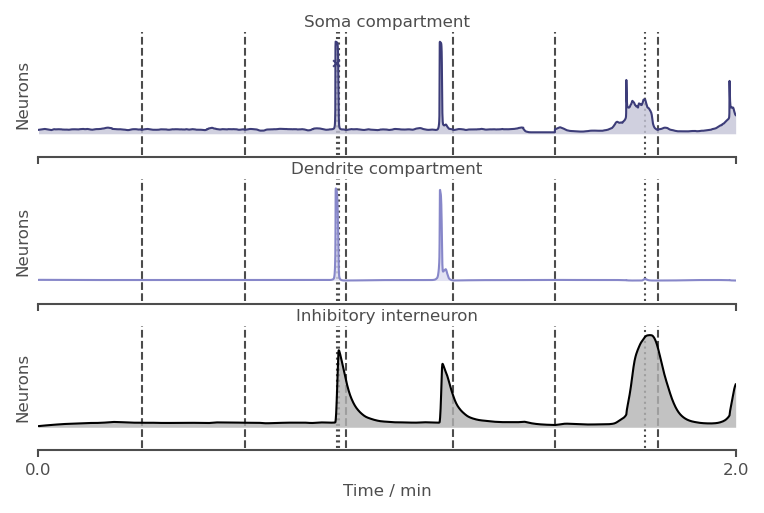

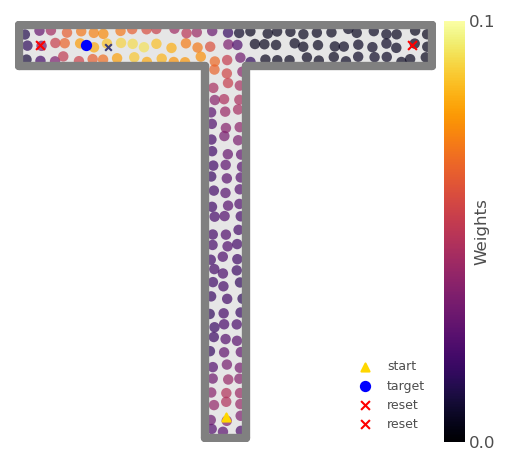

In [102]:
CA1s.plot_rate_timeseries(separate_axes=True)

fig, ax = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax, s=25, plot_BTSP_events=True);

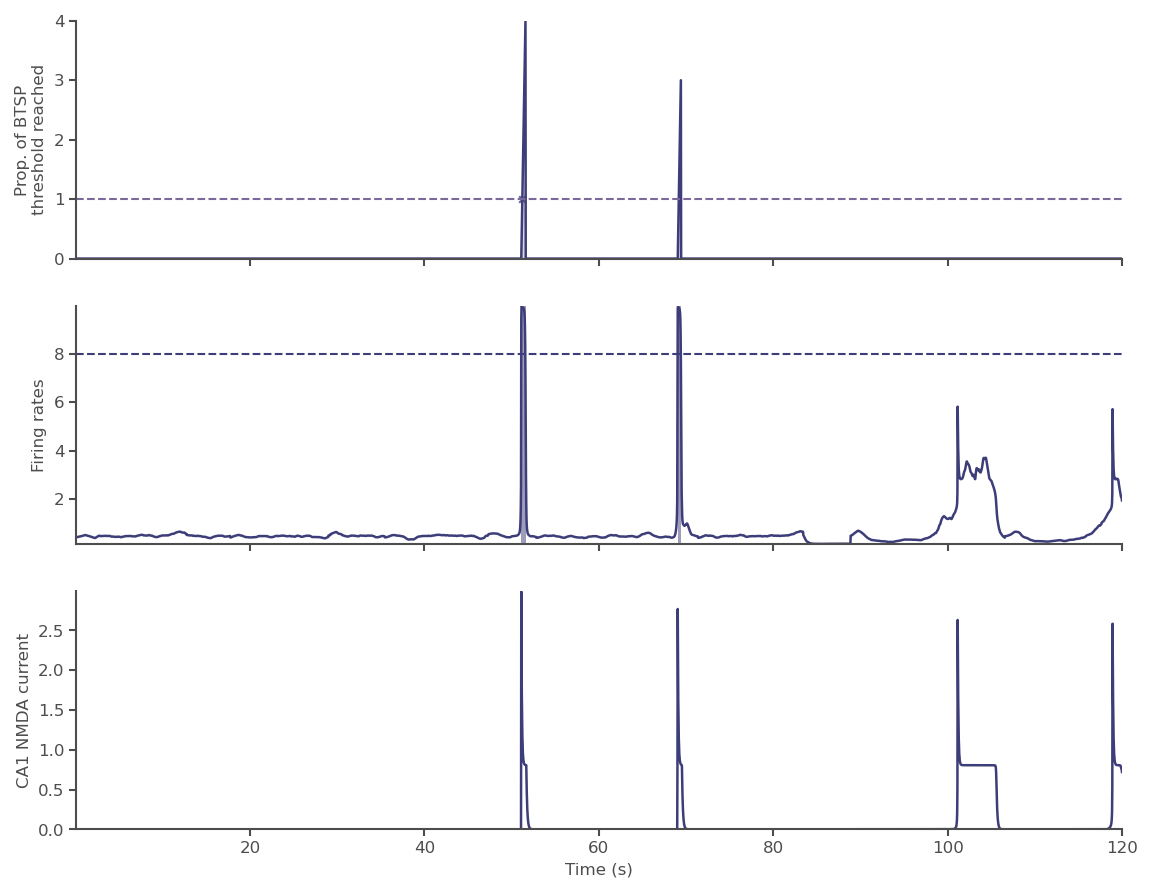

In [103]:
CA1s.SomaCompartment.plot_BTSP_ramp();

BTSP events applied after 1075.00 steps (32.25 sec.) (num steps: 1075).


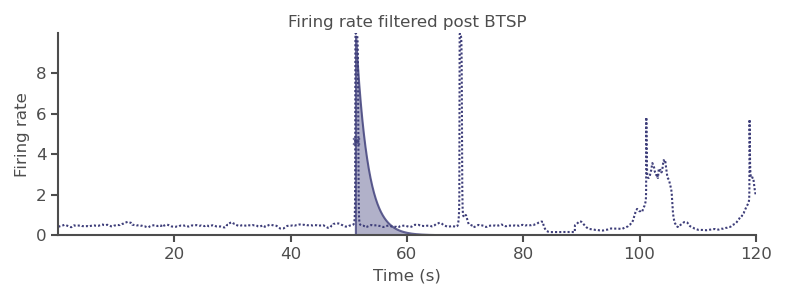

In [104]:
CA1s.SomaCompartment.log_num_steps_to_apply_BTSP()
CA1s.SomaCompartment.plot_filtered_for_BTSP();

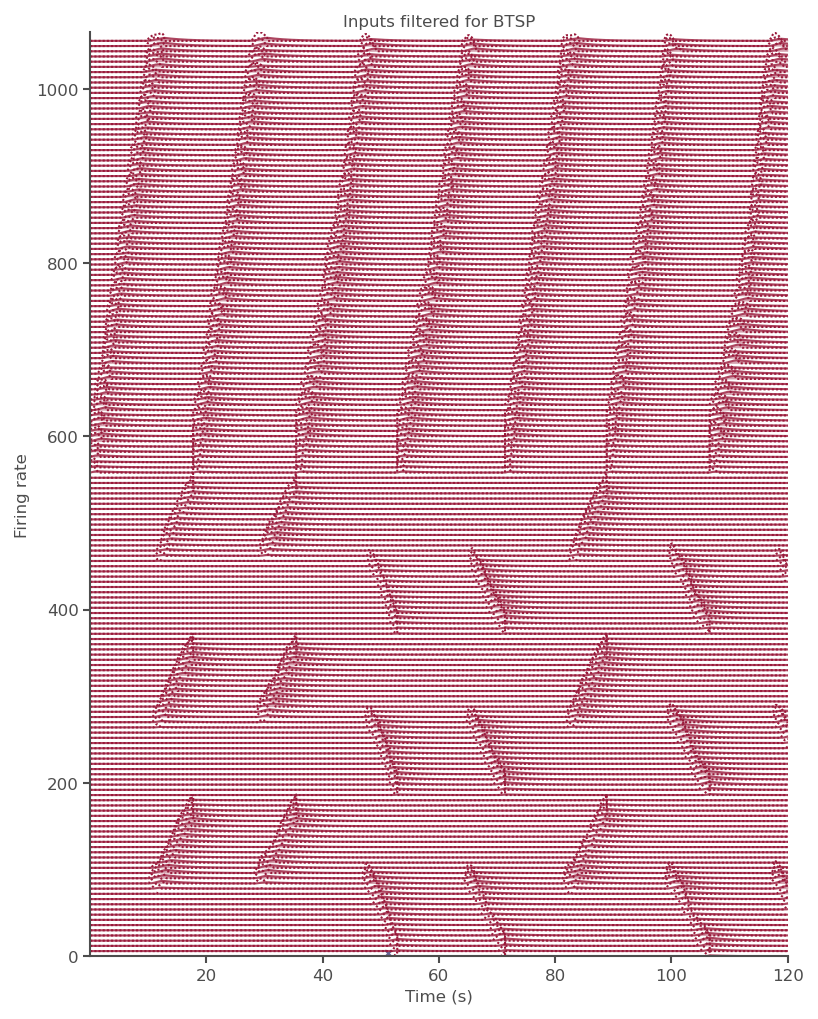

In [105]:
CA1s.SomaCompartment.plot_filtered_for_BTSP("CA3_PCs");

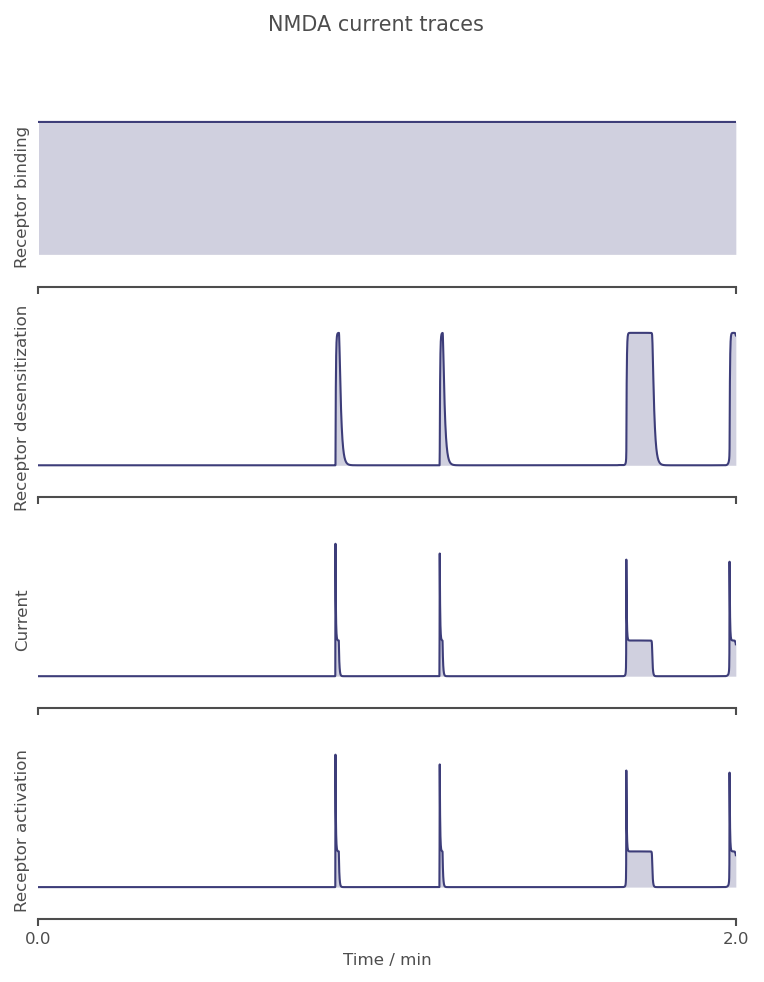

In [106]:
CA1s.SomaCompartment.inputs["NMDACurrent"]["layer"].plot_timeseries(datatypes="all");

In [107]:
Ag.target_df

,target_arm,position_x,position_y,set_step,set_time,reached_step,reached_time,num_steps_total,time_total
0,left,0.325,1.9,0,0.00,1713.0,51.39,1713.0,51.39
1,left,0.325,1.9,1713,51.39,1724.0,51.72,11.0,0.33
2,left,0.325,1.9,1724,51.72,3479.0,104.37,1755.0,52.65
3,left,0.325,1.9,3479,104.37,NaN,NaN,NaN,NaN


In [108]:
Ag.trajectory_df

,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,1.000485,0.098924,0,0.00,1.859500,1.857696,591.0,17.73,591.0,17.73
1,1.001070,0.099876,591,17.73,1.866926,1.857696,1182.0,35.46,591.0,17.73
2,0.999851,0.100851,1182,35.46,0.135415,1.857696,1761.0,52.83,579.0,17.37
3,1.000597,0.100599,1761,52.83,0.141903,1.857696,2379.0,71.37,618.0,18.54
4,1.000070,0.099107,2379,71.37,1.874703,1.857696,2962.0,88.86,583.0,17.49
5,1.000870,0.100643,2962,88.86,0.106638,1.857696,3552.0,106.56,590.0,17.70
6,1.001180,0.100218,3552,106.56,NaN,NaN,NaN,NaN,NaN,NaN


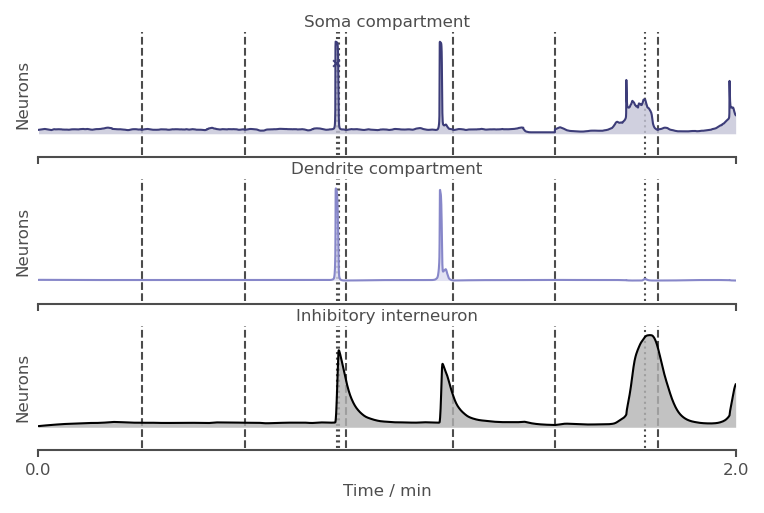

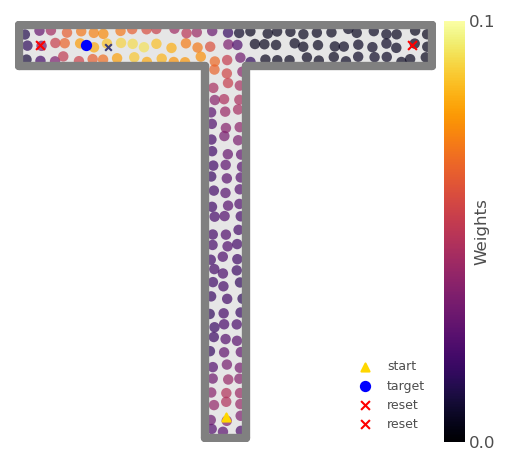

In [109]:
ax_time = CA1s.plot_rate_timeseries(separate_axes=True)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

## Move target

In [110]:
_, Ag, CA3_PCs, CA1s, ECs = run_manager.extract_objects_from_CA1s(CA1s)

CA1s.Agent.set_target_position([1, 1.3])

In [111]:
num_steps = 2500
for i in tqdm(range(2500)):
    Ag.update(speed_fact=3, drift_to_random_strength_ratio=1)
    ECs.update()
    CA3_PCs.update()
    CA1s.update()

100%|██████████| 2500/2500 [00:05<00:00, 490.87it/s]


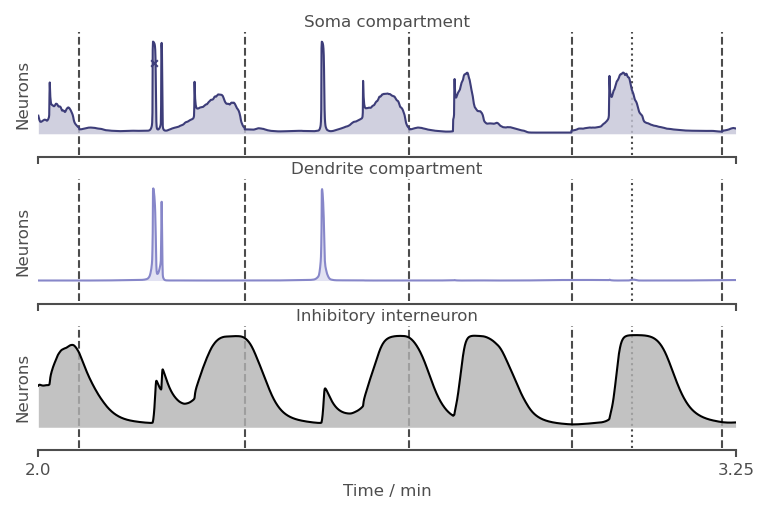

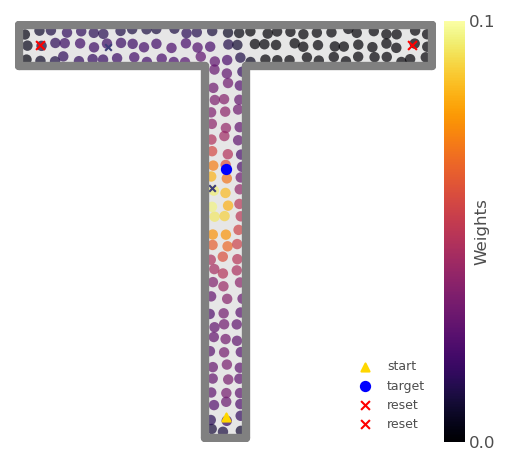

In [112]:
ax_time = CA1s.plot_rate_timeseries(t_start=2*60, separate_axes=True)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

## Test wrong parameters

In [113]:
INHIBIT_WEIGHT = 0.5 # too low

In [114]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

agent_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

CA1_params = params_util.get_CA1_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=400,
    inhibit_weight=INHIBIT_WEIGHT
)

100%|██████████| 6000/6000 [00:12<00:00, 475.65it/s]


Trajectory lengths (10) to date: 18.00 +/- 1.44 sec each
Trajectory lengths (10) to date: 600.00 +/- 48.03 steps each


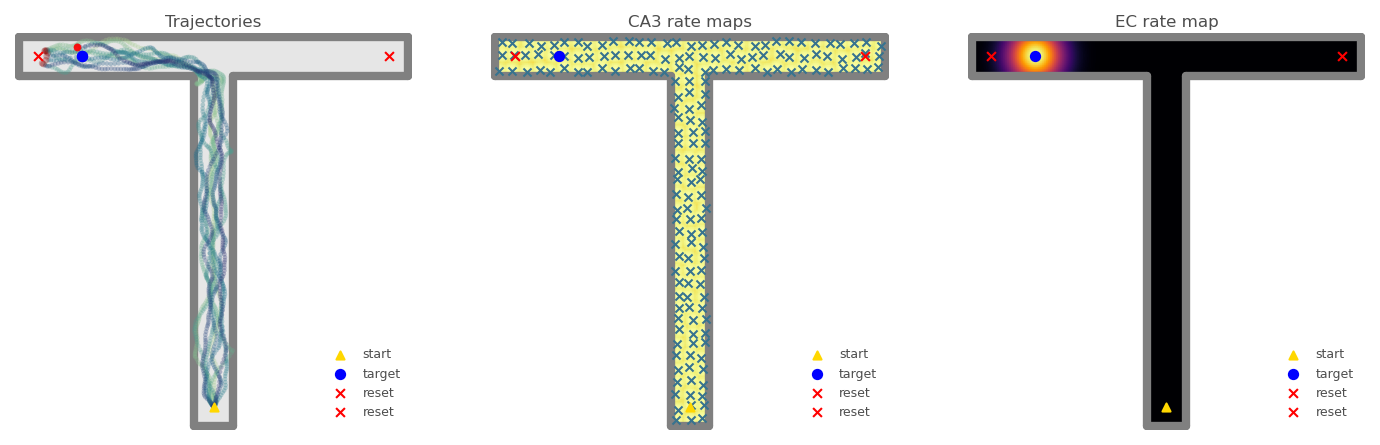

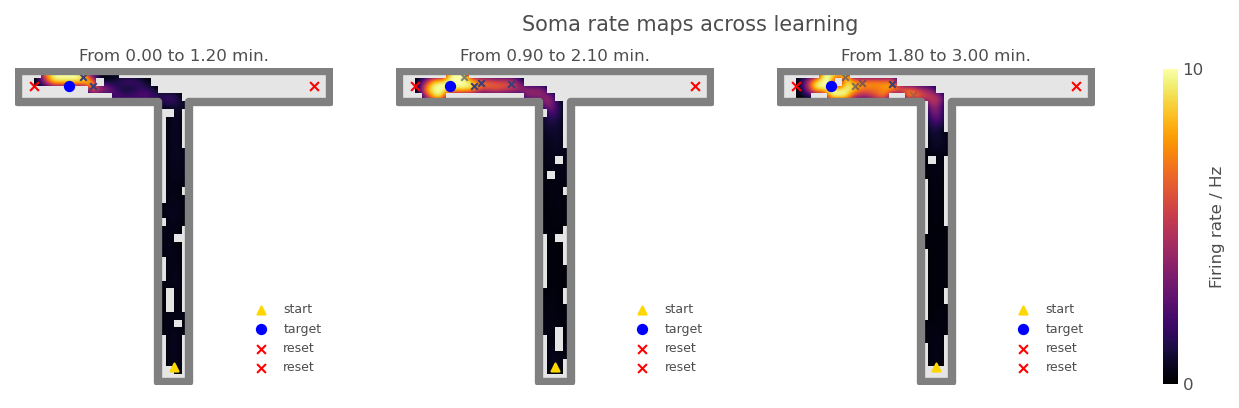

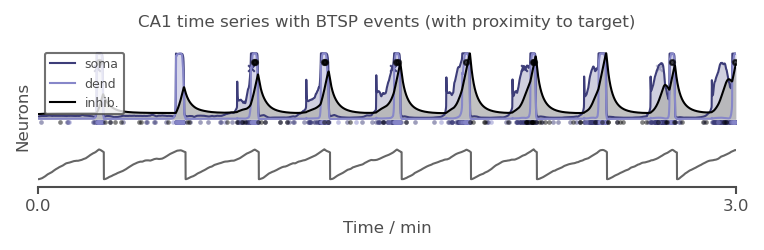

In [115]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

CA1s = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    CA3_PC_params=CA3_PC_params, 
    CA1_params=CA1_params, 
    num_rewards=12, 
    max_num_steps=6000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

_, Ag, CA3_PCs, CA1s, ECs = run_manager.extract_objects_from_CA1s(CA1s)

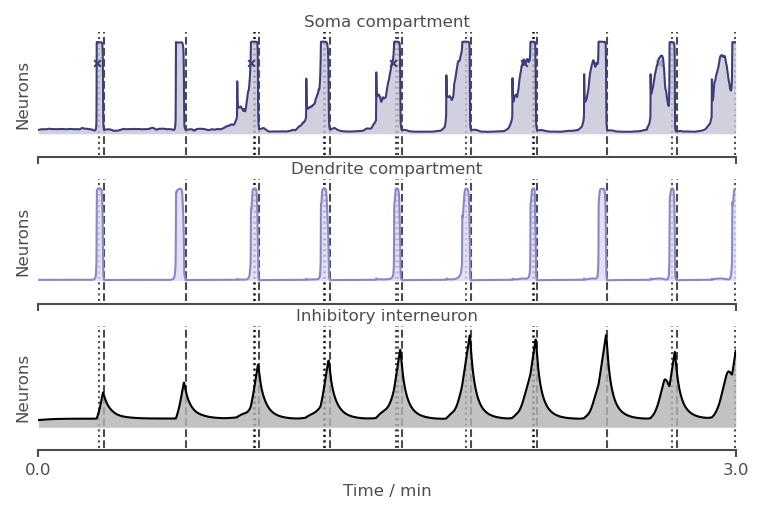

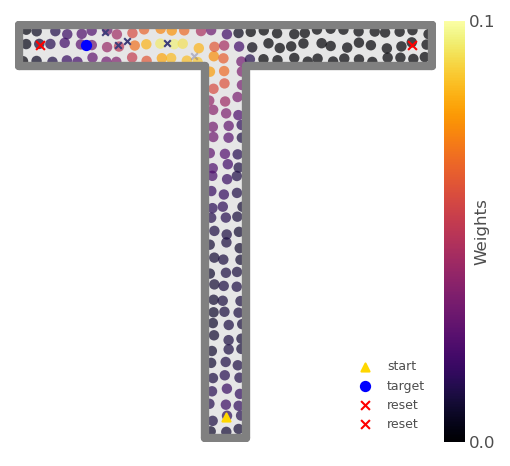

In [116]:
ax_time = CA1s.plot_rate_timeseries(separate_axes=True)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

In [117]:
INHIBIT_WEIGHT = 5.0 # too high

In [118]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

agent_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

CA1_params = params_util.get_CA1_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=400,
    inhibit_weight=INHIBIT_WEIGHT
)

100%|██████████| 6000/6000 [00:12<00:00, 473.35it/s]


Only reached the reward 8 times (target: 12).
Trajectory lengths (10) to date: 18.00 +/- 3.04 sec each
Trajectory lengths (10) to date: 600.00 +/- 101.25 steps each


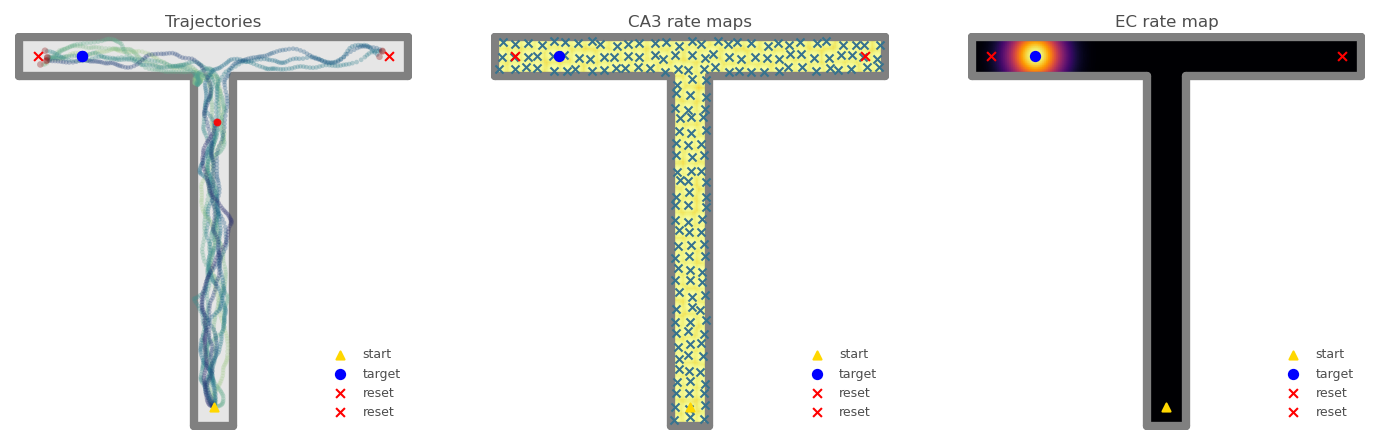

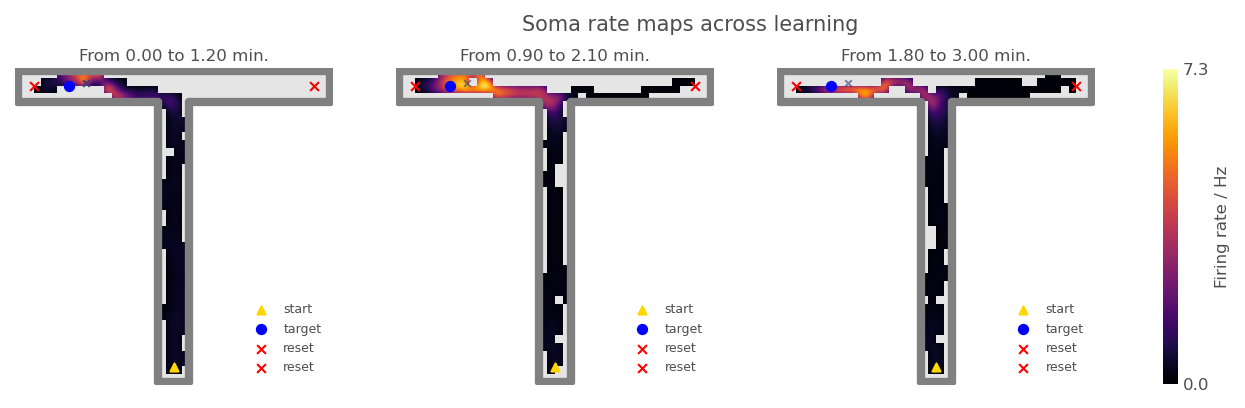

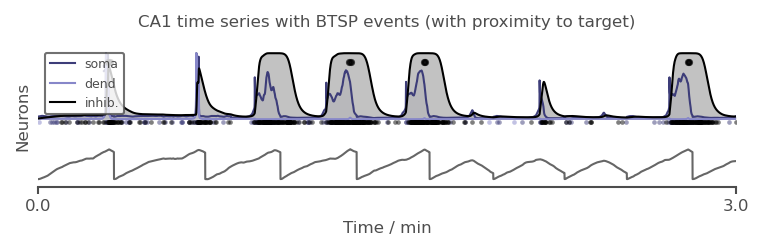

In [119]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

CA1s = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    CA3_PC_params=CA3_PC_params, 
    CA1_params=CA1_params, 
    num_rewards=12, 
    max_num_steps=6000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

_, Ag, CA3_PCs, CA1s, ECs = run_manager.extract_objects_from_CA1s(CA1s)

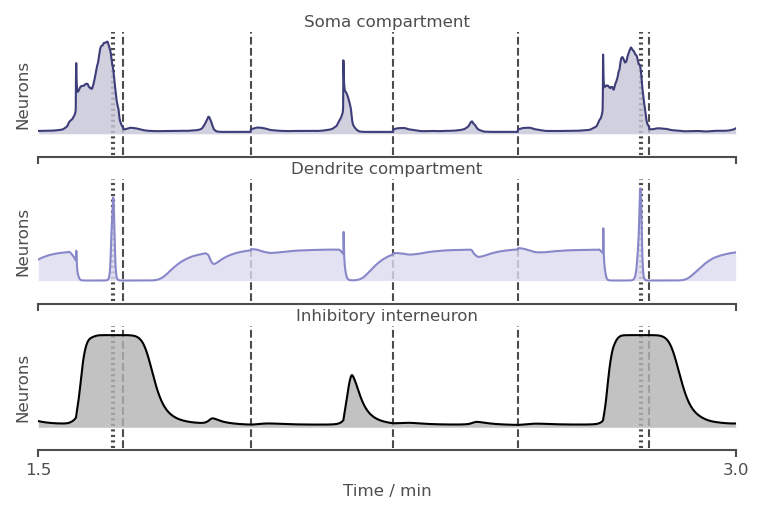

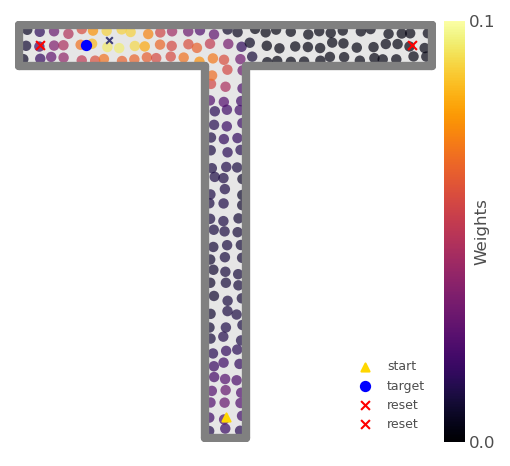

In [120]:
ax_time = CA1s.plot_rate_timeseries(separate_axes=True, t_start=90)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);